# 📊 Employee Attrition — Full Data Mining Package

This notebook covers a comprehensive data mining analysis of the employee attrition dataset. The following techniques are applied:

| # | Module | Technique |
|---|--------|-----------|
| 1 | Exploratory Data Analysis | Distribution, correlation, missing values |
| 2 | Association Rule Mining | Apriori algorithm to find attrition drivers |
| 3 | Classification | Decision Tree to predict attrition |
| 4 | Clustering | K-Means to find employee segments |
| 5 | Feature Importance | Which factors drive attrition the most? |
| 6 | Salary & Tenure Analysis | Income vs experience & attrition risk |
| 7 | Work-Life & Satisfaction Profiling | Satisfaction scores vs behavior |


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Styling
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pct_fmt = lambda x, _: f'{x:.0f}%'

print('✅ All imports successful.')

✅ All imports successful.


## 1. Load & Inspect Data

In [ ]:
df = pd.read_pickle('attrition_available_10.pkl')

# Drop useless constant columns
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True, errors='ignore')

# Binary target column
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

print(f'Shape: {df.shape}')
print(f'\nAttrition distribution:')
print(df['Attrition'].value_counts(dropna=False))
df.head()

Shape: (4410, 29)

Attrition distribution:
Attrition
No     3699
Yes     711
Name: count, dtype: int64


/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/pickle.py:329: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = getattr(obj, subpath)


,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,...,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary
1,7.315971,13.0,2.0,4.0,3.0,2.0,NaN,31.0,Yes,Travel_Frequently,...,41890.0,NaN,23.0,NaN,6.0,3.0,5.0,1,NaN,1
6,6.450877,17.0,NaN,4.0,1.0,NaN,1.0,28.0,Yes,Travel_Rarely,...,58130.0,NaN,20.0,1.0,5.0,2.0,0.0,0,0.0,1
13,8.871421,14.0,2.0,3.0,1.0,2.0,NaN,NaN,Yes,Non-Travel,...,57620.0,1.0,11.0,2.0,10.0,4.0,NaN,9,NaN,1
28,10.713066,6.0,2.0,3.0,4.0,3.0,1.0,44.0,Yes,Travel_Frequently,...,103330.0,3.0,14.0,NaN,19.0,2.0,1.0,0,0.0,1
30,9.662808,NaN,2.0,3.0,1.0,2.0,3.0,26.0,Yes,Travel_Rarely,...,68540.0,2.0,11.0,0.0,5.0,5.0,3.0,0,2.0,1


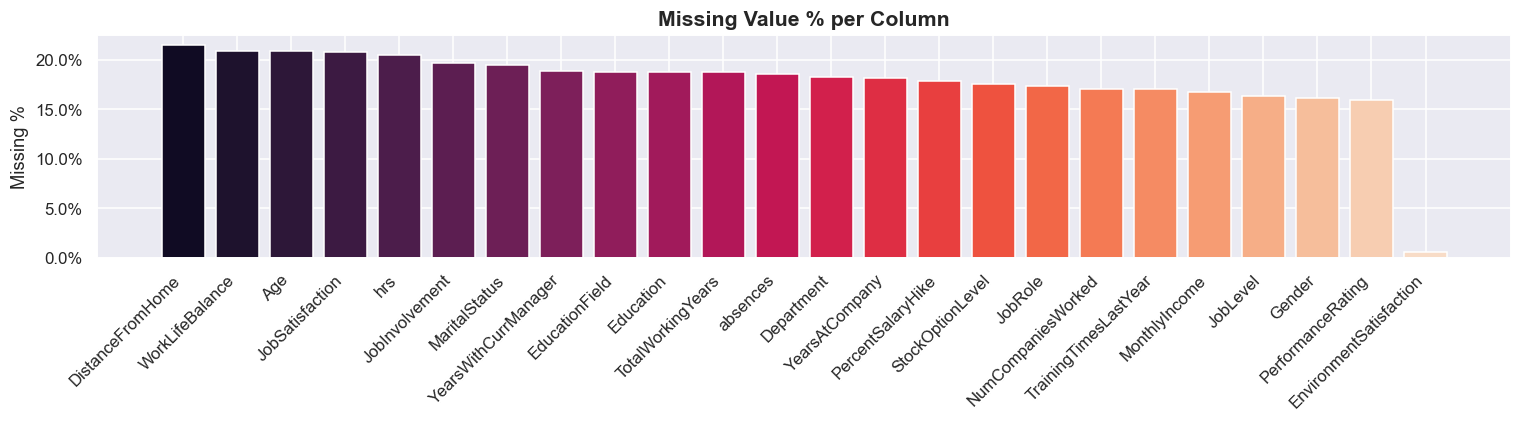

DistanceFromHome           21.428571
WorkLifeBalance            20.839002
Age                        20.839002
JobSatisfaction            20.770975
hrs                        20.453515
JobInvolvement             19.682540
MaritalStatus              19.478458
YearsWithCurrManager       18.888889
EducationField             18.752834
Education                  18.752834
TotalWorkingYears          18.730159
absences                   18.503401
Department                 18.208617
YearsAtCompany             18.163265
PercentSalaryHike          17.868481
StockOptionLevel           17.482993
JobRole                    17.369615
NumCompaniesWorked         17.029478
TrainingTimesLastYear      17.006803
MonthlyIncome              16.757370
JobLevel                   16.349206
Gender                     16.167800
PerformanceRating          15.963719
EnvironmentSatisfaction     0.566893


In [3]:
# ── Missing Value Heatmap ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
bars = ax.bar(missing_pct.index, missing_pct.values, color=sns.color_palette('rocket', len(missing_pct)))
ax.set_title('Missing Value % per Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(missing_pct.to_string())

## 2. Exploratory Data Analysis (EDA)

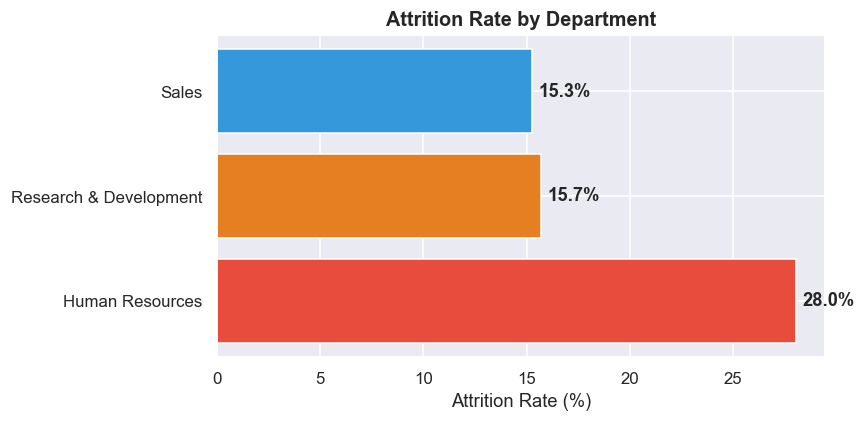

In [4]:
# ── 2a. Attrition Rate by Department ─────────────────────────────────────────
dept = df.groupby('Department')['Attrition_Binary'].agg(['sum', 'count'])
dept['rate'] = dept['sum'] / dept['count'] * 100
dept = dept.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(dept.index, dept['rate'], color=['#e74c3c', '#e67e22', '#3498db'])
for bar, val in zip(bars, dept['rate']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

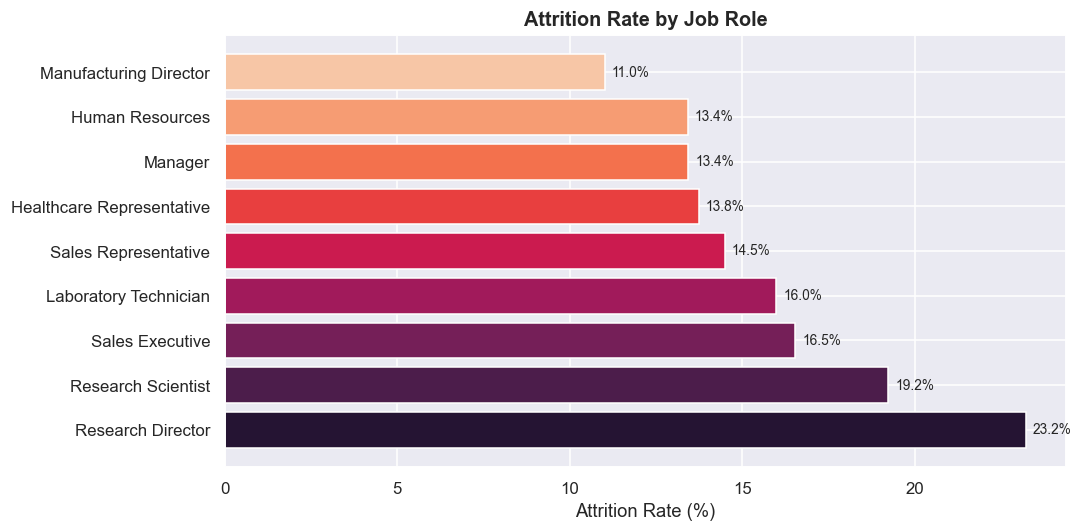

In [5]:
# ── 2b. Attrition Rate by Job Role ───────────────────────────────────────────
role_attr = df.groupby('JobRole')['Attrition_Binary'].agg(['sum', 'count'])
role_attr['rate'] = role_attr['sum'] / role_attr['count'] * 100
role_attr = role_attr.sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
pal = sns.color_palette('rocket', len(role_attr))
bars = ax.barh(role_attr.index, role_attr['rate'], color=pal)
for bar, val in zip(bars, role_attr['rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

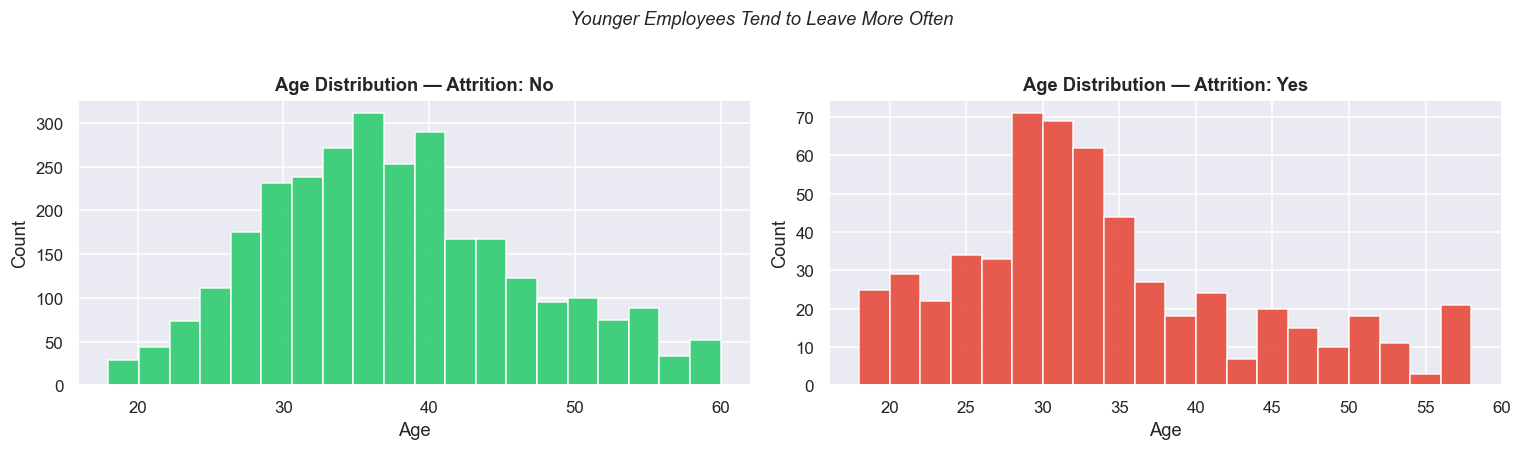

Median Age — Stayed: 36.0
Median Age — Left:   31.0


In [ ]:
# ── 2c. Age Distribution: Attrited vs Stayed ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, grp) in zip(axes, df.groupby('Attrition')):
    ax.hist(grp['Age'].dropna(), bins=20, color='#e74c3c' if label == 'Yes' else '#2ecc71', 
            edgecolor='white', alpha=0.9)
    ax.set_title(f'Age Distribution — Attrition: {label}', fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

plt.suptitle('Younger Employees Tend to Leave More Often', y=1.02, fontsize=12, fontstyle='italic')
plt.tight_layout()
plt.show()

print('Median Age — Stayed:', df[df['Attrition']=='No']['Age'].median())
print('Median Age — Left:  ', df[df['Attrition']=='Yes']['Age'].median())

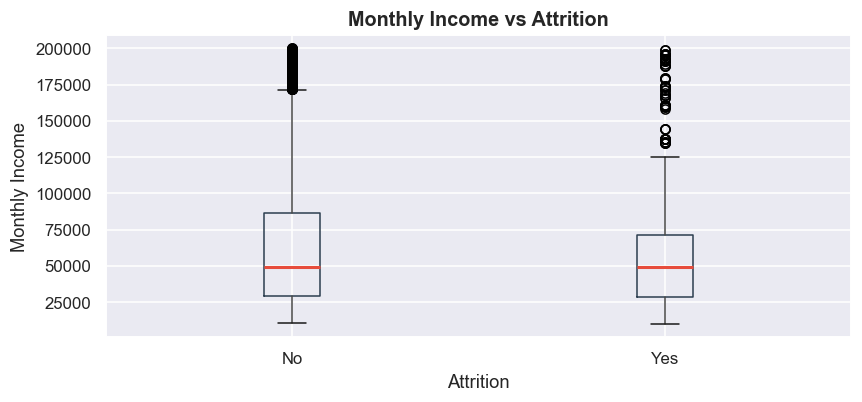

Median Income — Stayed: 48980.0
Median Income — Left:   49040.0


In [7]:
# ── 2d. Monthly Income vs Attrition ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='MonthlyIncome', by='Attrition', ax=ax, 
           boxprops=dict(color='#2c3e50'), medianprops=dict(color='#e74c3c', lw=2))
ax.set_title('Monthly Income vs Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Monthly Income')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Median Income — Stayed:', df[df['Attrition']=='No']['MonthlyIncome'].median())
print('Median Income — Left:  ', df[df['Attrition']=='Yes']['MonthlyIncome'].median())

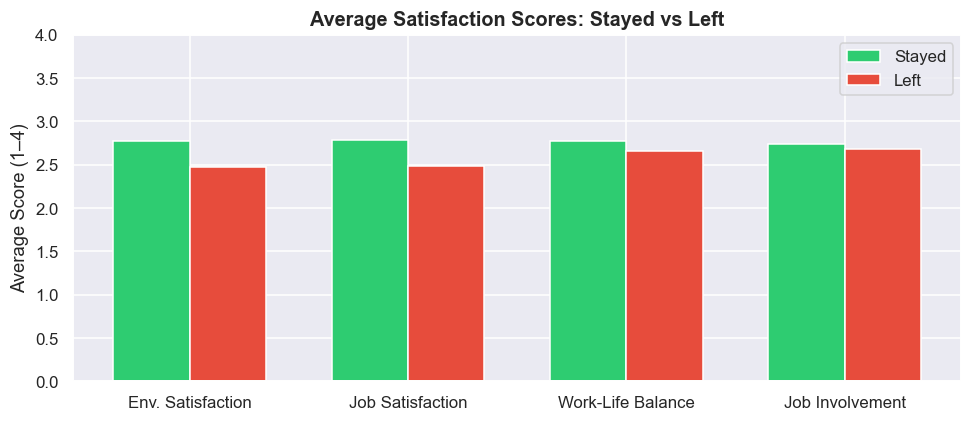

Attrition                      No       Yes
EnvironmentSatisfaction  2.772493  2.468839
JobSatisfaction          2.783885  2.481416
WorkLifeBalance          2.777170  2.661947
JobInvolvement           2.736116  2.683012


In [8]:
# ── 2e. Satisfaction Scores ───────────────────────────────────────────────────
sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
sat_means = df.groupby('Attrition')[sat_cols].mean()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(sat_cols))
w = 0.35
ax.bar(x - w/2, sat_means.loc['No'], w, label='Stayed', color='#2ecc71')
ax.bar(x + w/2, sat_means.loc['Yes'], w, label='Left', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(['Env. Satisfaction', 'Job Satisfaction', 'Work-Life Balance', 'Job Involvement'])
ax.set_ylabel('Average Score (1–4)')
ax.set_title('Average Satisfaction Scores: Stayed vs Left', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 4)
plt.tight_layout()
plt.show()
print(sat_means.T)

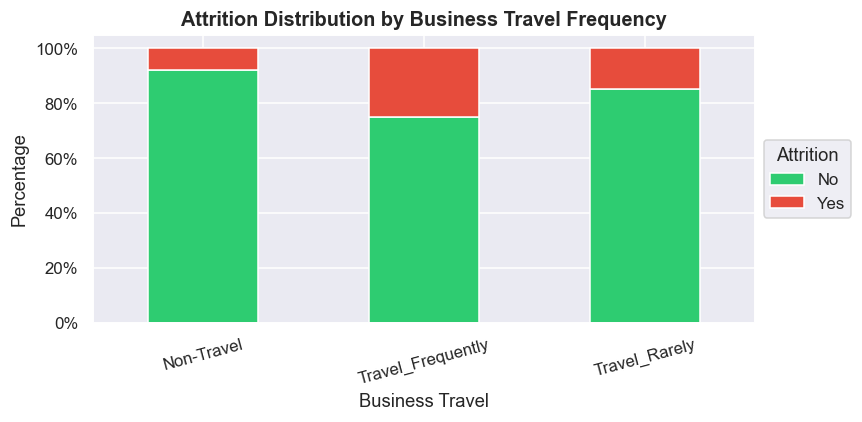

In [9]:
# ── 2f. Business Travel vs Attrition ─────────────────────────────────────────
travel = df.groupby(['BusinessTravel', 'Attrition']).size().unstack().fillna(0)
travel_pct = travel.div(travel.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
travel_pct.plot(kind='bar', stacked=True, ax=ax,
                color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('Attrition Distribution by Business Travel Frequency', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('Business Travel')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Attrition', loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

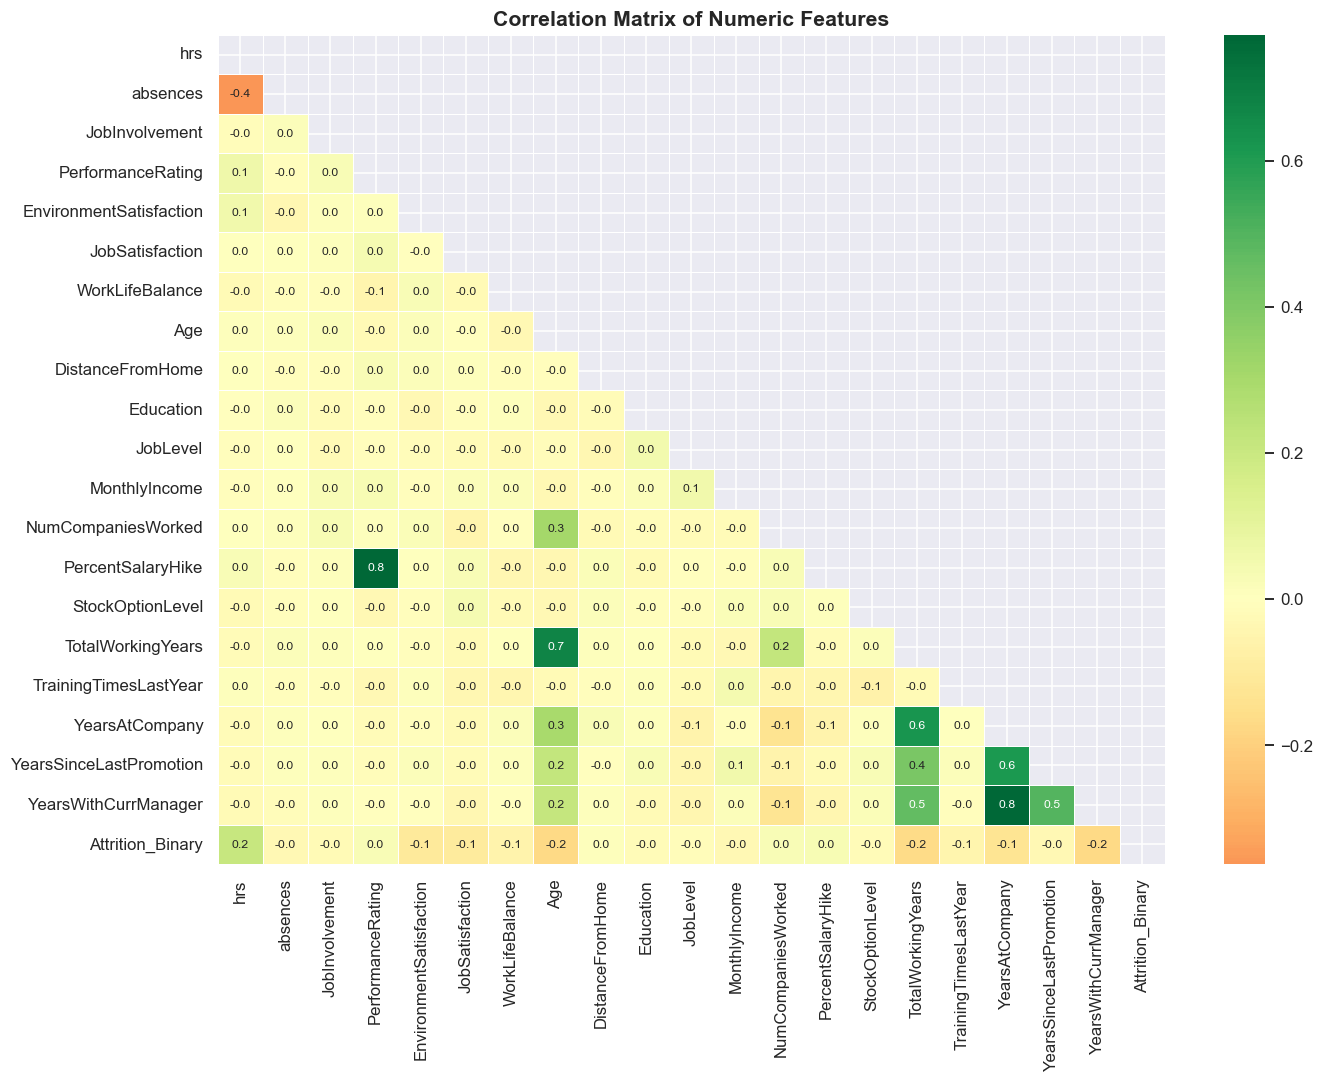

In [10]:
# ── 2g. Correlation Heatmap (Numeric Features) ────────────────────────────────
num_cols = df.select_dtypes(include=np.number).drop(columns=['EmployeeID'], errors='ignore')
corr = num_cols.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Association Rule Mining (Apriori) — Why Employees Leave

In [11]:
# ── Prepare Apriori Transactions ─────────────────────────────────────────────
apriori_cols = ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus',
                'BusinessTravel', 'EnvironmentSatisfaction', 'JobSatisfaction',
                'WorkLifeBalance', 'PerformanceRating', 'Attrition']

df_ap = df[[c for c in apriori_cols if c in df.columns]].copy().dropna()

# Discretize ordinal numeric columns
df_ap['EnvironmentSatisfaction'] = df_ap['EnvironmentSatisfaction'].apply(lambda x: 'EnvSat_Low' if x <= 2 else 'EnvSat_High')
df_ap['JobSatisfaction']         = df_ap['JobSatisfaction'].apply(lambda x: 'JobSat_Low' if x <= 2 else 'JobSat_High')
df_ap['WorkLifeBalance']         = df_ap['WorkLifeBalance'].apply(lambda x: 'WLB_Low' if x <= 2 else 'WLB_High')
df_ap['PerformanceRating']       = df_ap['PerformanceRating'].apply(lambda x: 'Perf_Low' if x <= 3 else 'Perf_High')

# Prefix each value with column name to avoid ambiguity
for col in df_ap.columns:
    if col != 'Attrition':
        df_ap[col] = col + '_' + df_ap[col].astype(str)
df_ap['Attrition'] = 'Attrition_' + df_ap['Attrition']

transactions = df_ap.values.tolist()
print(f'Transactions ready: {len(transactions)} rows')

# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_ary, columns=te.columns_)

# ── Run Apriori ───────────────────────────────────────────────────────────────
# min_support=0.01 is intentionally low because Attrition=Yes is a minority class (~16%)
# min_confidence=0.1 is low for the same reason — we prioritise Lift (strength of association) instead
freq_items = apriori(df_te, min_support=0.01, use_colnames=True)
rules = association_rules(freq_items, metric='confidence', min_threshold=0.1)

# Filter rules where consequent contains Attrition_Yes
yes_rules = rules[rules['consequents'].apply(lambda x: 'Attrition_Yes' in x)]
yes_rules = yes_rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print(f'\nTotal rules found: {len(rules)}')
print(f'Rules predicting Attrition=Yes: {len(yes_rules)}')

Transactions ready: 851 rows



Total rules found: 1208447
Rules predicting Attrition=Yes: 8441


In [12]:
# ── Top 10 Attrition Rules (readable format) ─────────────────────────────────
print('='*70)
print('TOP 10 ASSOCIATION RULES → Attrition = Yes')
print('='*70)
for i, (_, row) in enumerate(yes_rules.head(10).iterrows(), 1):
    ants = ', '.join(sorted(row['antecedents']))
    print(f'\n[Rule {i}]')
    print(f'  IF   : {ants}')
    print(f'  THEN : Attrition = Yes')
    print(f'  Support={row["support"]:.4f}  Confidence={row["confidence"]:.4f}  Lift={row["lift"]:.4f}')

TOP 10 ASSOCIATION RULES → Attrition = Yes

[Rule 1]
  IF   : EducationField_Marketing, EnvironmentSatisfaction_EnvSat_Low
  THEN : Attrition = Yes
  Support=0.0106  Confidence=0.2432  Lift=10.3500

[Rule 2]
  IF   : BusinessTravel_Travel_Rarely, EducationField_Marketing, EnvironmentSatisfaction_EnvSat_Low
  THEN : Attrition = Yes
  Support=0.0106  Confidence=0.3000  Lift=9.8192

[Rule 3]
  IF   : BusinessTravel_Travel_Rarely, EducationField_Marketing, PerformanceRating_Perf_Low
  THEN : Attrition = Yes
  Support=0.0106  Confidence=0.1500  Lift=9.8192

[Rule 4]
  IF   : BusinessTravel_Travel_Rarely, EducationField_Marketing, EnvironmentSatisfaction_EnvSat_Low, PerformanceRating_Perf_Low
  THEN : Attrition = Yes
  Support=0.0106  Confidence=0.3462  Lift=9.5025

[Rule 5]
  IF   : EducationField_Marketing, EnvironmentSatisfaction_EnvSat_Low, PerformanceRating_Perf_Low
  THEN : Attrition = Yes
  Support=0.0106  Confidence=0.2727  Lift=9.2836

[Rule 6]
  IF   : EducationField_Marketing, Env

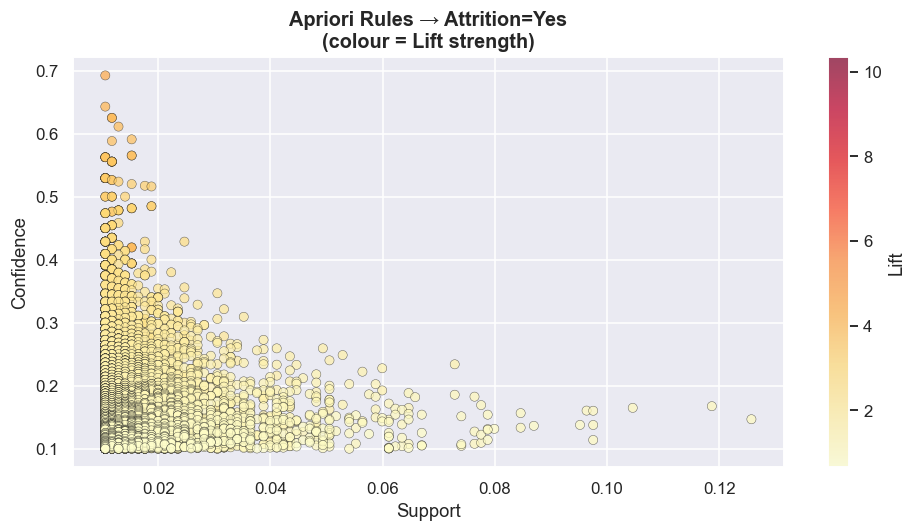

In [13]:
# ── Support vs Confidence scatter coloured by Lift ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(yes_rules['support'], yes_rules['confidence'],
                c=yes_rules['lift'], cmap='YlOrRd', alpha=0.7, edgecolors='k', linewidths=0.3)
fig.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Apriori Rules → Attrition=Yes\n(colour = Lift strength)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Classification — Predicting Attrition (Decision Tree & Random Forest)

In [14]:
# ── Prepare Classification Data ───────────────────────────────────────────────
clf_cols = ['Age', 'Department', 'DistanceFromHome', 'Education', 'EducationField',
            'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel',
            'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
            'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
            'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
            'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion',
            'YearsWithCurrManager', 'BusinessTravel', 'Attrition_Binary']

df_clf = df[[c for c in clf_cols if c in df.columns]].dropna().copy()

# Encode categorical features
cat_cols = df_clf.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_clf[col] = le.fit_transform(df_clf[col])

X = df_clf.drop(columns=['Attrition_Binary'])
y = df_clf['Attrition_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f'Train size: {len(X_train)}  |  Test size: {len(X_test)}')
print(f'Class balance in test: {y_test.value_counts().to_dict()}')

Train size: 44  |  Test size: 15
Class balance in test: {0: 13, 1: 2}


DECISION TREE — Classification Report
              precision    recall  f1-score   support

      Stayed       0.93      1.00      0.96        13
        Left       1.00      0.50      0.67         2

    accuracy                           0.93        15
   macro avg       0.96      0.75      0.81        15
weighted avg       0.94      0.93      0.92        15



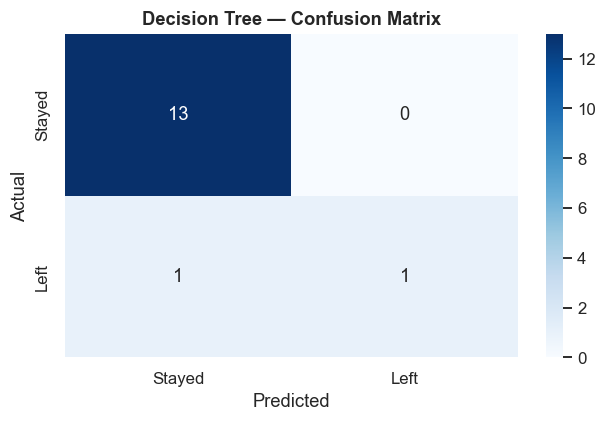

In [15]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('DECISION TREE — Classification Report')
print(classification_report(y_test, y_pred_dt, target_names=['Stayed', 'Left']))

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
ax.set_title('Decision Tree — Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

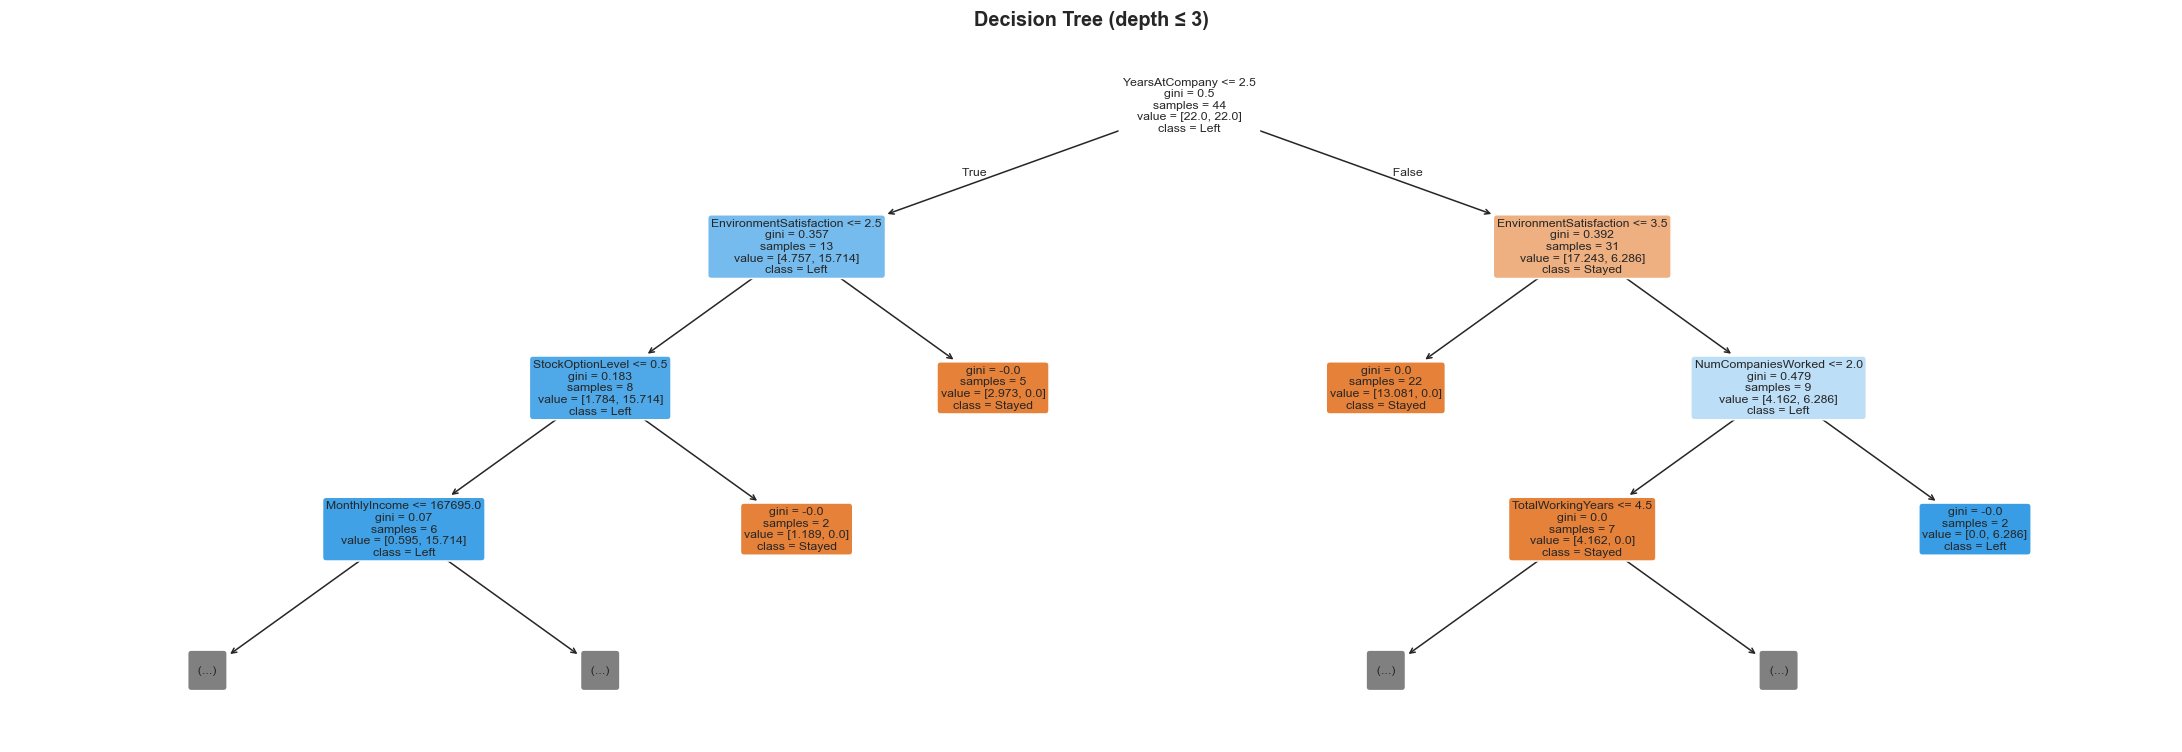

In [16]:
# ── Decision Tree Visualisation (first 3 levels) ──────────────────────────────
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(dt, max_depth=3, feature_names=X.columns,
          class_names=['Stayed', 'Left'], filled=True,
          rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree (depth ≤ 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('RANDOM FOREST — Classification Report')
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      Stayed       0.87      1.00      0.93        13
        Left       0.00      0.00      0.00         2

    accuracy                           0.87        15
   macro avg       0.43      0.50      0.46        15
weighted avg       0.75      0.87      0.80        15



## 5. Feature Importance — What Drives Attrition?

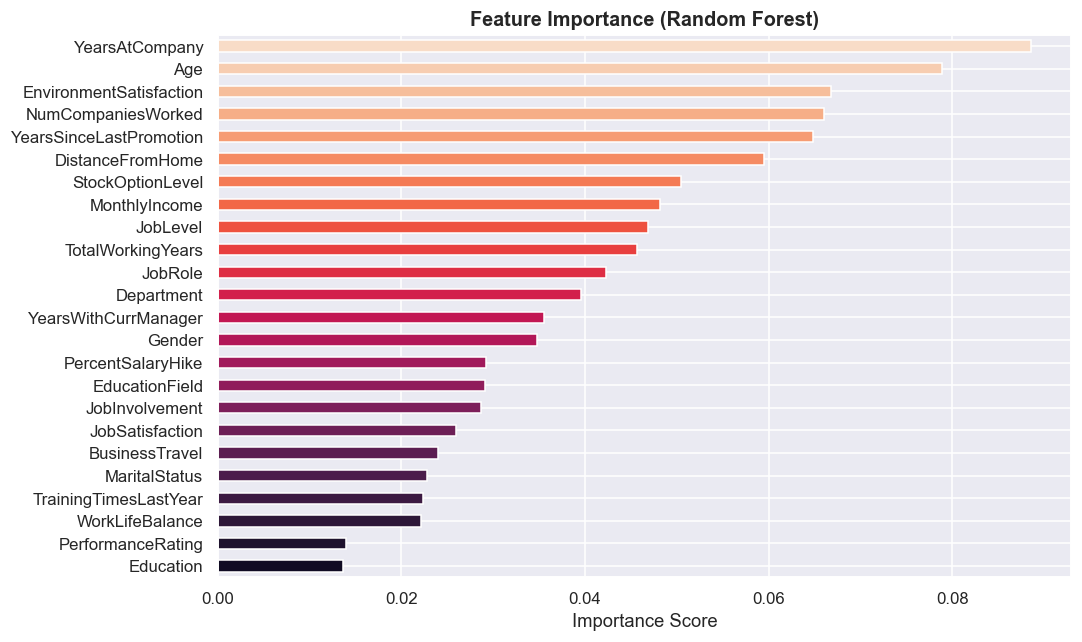


Top 10 Features:
YearsAtCompany             0.088565
Age                        0.078919
EnvironmentSatisfaction    0.066793
NumCompaniesWorked         0.066034
YearsSinceLastPromotion    0.064860
DistanceFromHome           0.059488
StockOptionLevel           0.050431
MonthlyIncome              0.048205
JobLevel                   0.046914
TotalWorkingYears          0.045627


In [18]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('rocket', len(feat_imp))
feat_imp.plot(kind='barh', ax=ax, color=palette[::-1])
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 Features:')
print(feat_imp.head(10).to_string())

## 6. Clustering — Discovering Employee Segments (K-Means)

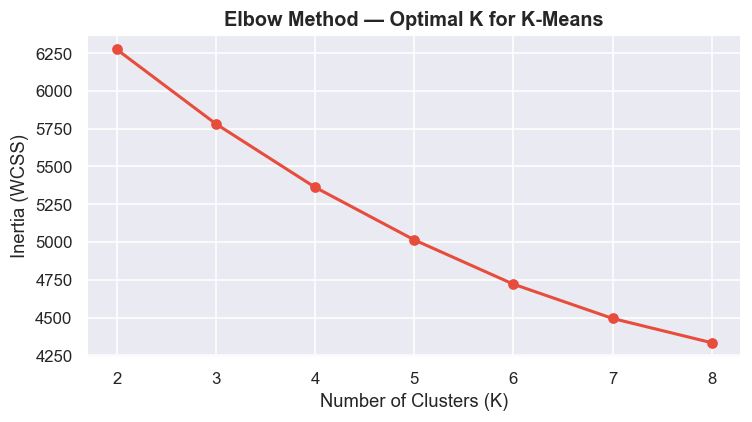

In [19]:
# ── Elbow Method to Find Optimal K ───────────────────────────────────────────
cluster_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                    'DistanceFromHome', 'PercentSalaryHike', 'YearsSinceLastPromotion']

df_clust = df[[c for c in cluster_features if c in df.columns]].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker='o', color='#e74c3c', lw=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method — Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── Apply K=4 (adjust after viewing elbow) ───────────────────────────────────
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
df_clust = df_clust.copy()
df_clust['Cluster'] = labels

# Merge Attrition back for analysis
df_clust['Attrition'] = df.loc[df_clust.index, 'Attrition']

print('Cluster Sizes:')
print(df_clust['Cluster'].value_counts().sort_index())

print('\nAttrition Rate per Cluster:')
print(df_clust.groupby('Cluster')['Attrition'].apply(lambda x: (x=='Yes').sum()/len(x)*100).round(1))

Cluster Sizes:
Cluster
0    265
1    122
2    227
3    138
Name: count, dtype: int64

Attrition Rate per Cluster:
Cluster
0    18.5
1    11.5
2    13.7
3    13.8
Name: Attrition, dtype: float64


/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' d

/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/Users/arulkevin/Desktop/Data Mining/venv/lib/python3.9/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarn

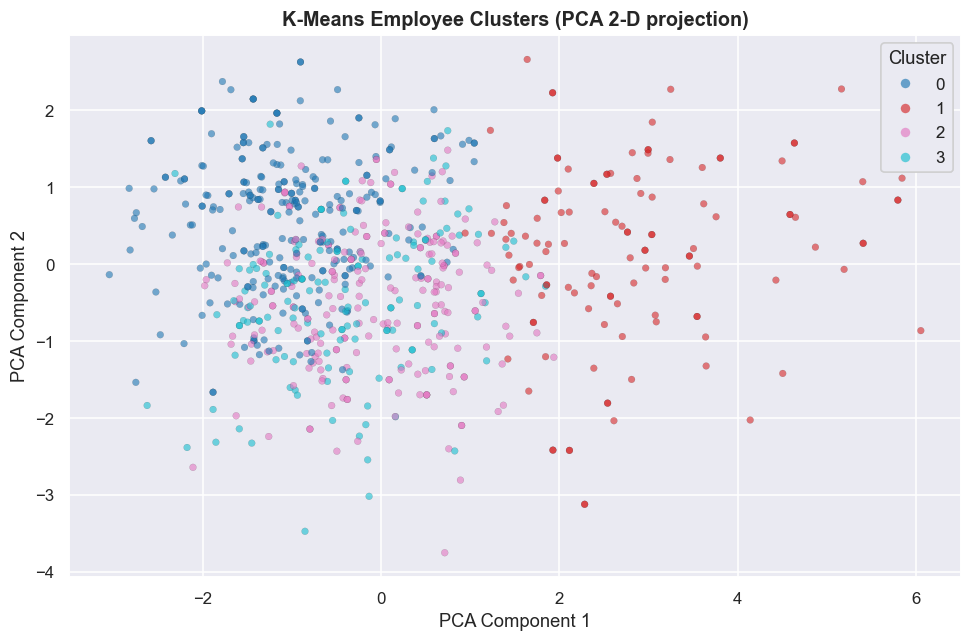

In [21]:
# ── PCA 2-D Cluster Visualisation ────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                     cmap='tab10', alpha=0.6, s=20, edgecolors='k', linewidths=0.1)
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)
ax.set_title('K-Means Employee Clusters (PCA 2-D projection)', fontsize=13, fontweight='bold')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

In [22]:
# ── Cluster Profile Summary ───────────────────────────────────────────────────
profile_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'JobSatisfaction', 'WorkLifeBalance', 'YearsSinceLastPromotion']
cluster_profile = df_clust.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile['Attrition_Rate_%'] = df_clust.groupby('Cluster')['Attrition'].apply(
    lambda x: round((x=='Yes').sum()/len(x)*100, 1))

print('\n=== Cluster Profile Summary ===')
print(cluster_profile.T.to_string())


=== Cluster Profile Summary ===
Cluster                         0         1         2         3
Age                         30.82     46.19     39.60     35.54
MonthlyIncome            74923.77  73160.49  52327.80  63426.16
TotalWorkingYears            6.87     23.75     11.52      9.51
YearsAtCompany               4.81     16.09      5.44      5.78
JobSatisfaction              2.38      2.71      2.85      2.91
WorkLifeBalance              2.95      2.63      2.47      2.83
YearsSinceLastPromotion      1.02      7.16      1.52      1.88
Attrition_Rate_%            18.50     11.50     13.70     13.80


## 7. Salary & Tenure Insights

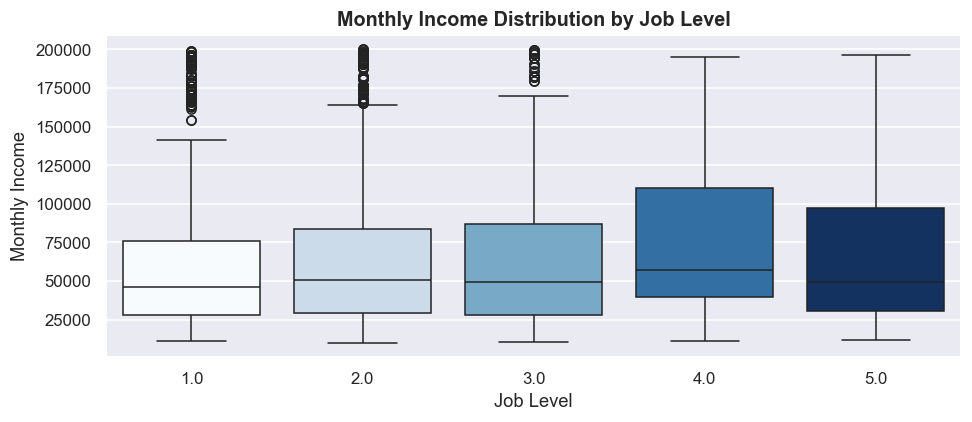

In [23]:
# ── 7a. Monthly Income by Job Level ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df.dropna(subset=['JobLevel', 'MonthlyIncome']),
            x='JobLevel', y='MonthlyIncome', ax=ax,
            palette='Blues', hue='JobLevel', legend=False)
ax.set_title('Monthly Income Distribution by Job Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Job Level')
ax.set_ylabel('Monthly Income')
plt.tight_layout()
plt.show()

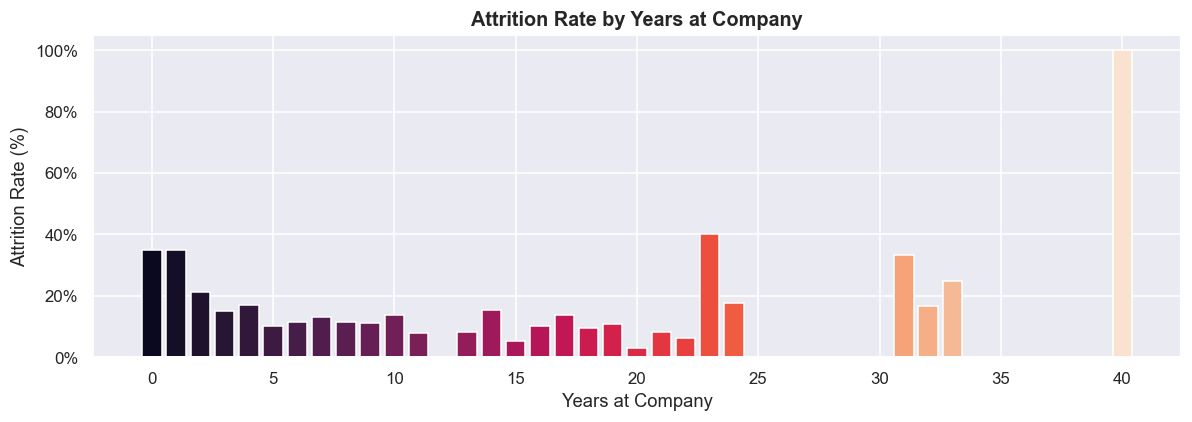

In [24]:
# ── 7b. Years at Company vs Attrition ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
yrs_attr = df.groupby('YearsAtCompany')['Attrition_Binary'].mean() * 100
ax.bar(yrs_attr.index, yrs_attr.values, color=sns.color_palette('rocket', len(yrs_attr)))
ax.set_title('Attrition Rate by Years at Company', fontsize=13, fontweight='bold')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Attrition Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

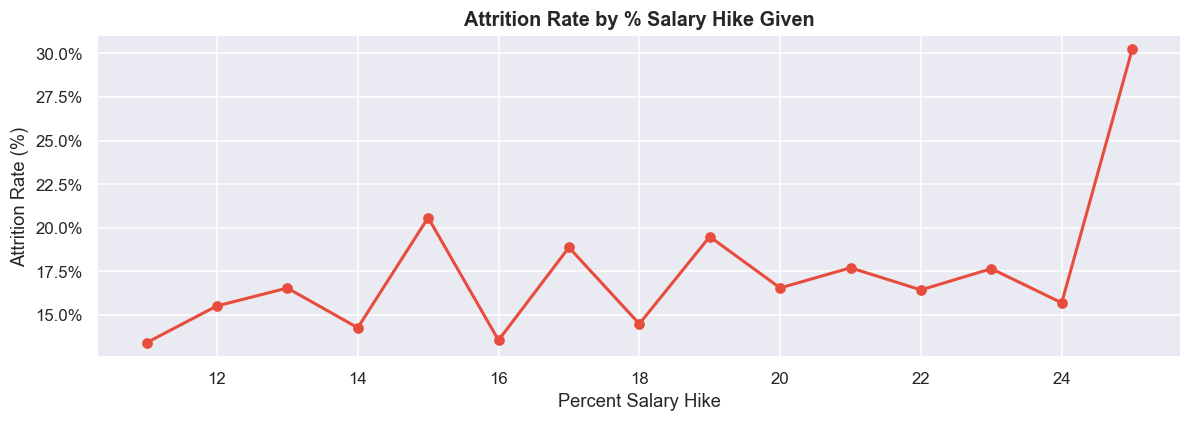

In [25]:
# ── 7c. Percent Salary Hike vs Attrition ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
hike_attr = df.groupby('PercentSalaryHike')['Attrition_Binary'].mean() * 100
ax.plot(hike_attr.index, hike_attr.values, marker='o', color='#e74c3c', lw=2)
ax.set_title('Attrition Rate by % Salary Hike Given', fontsize=13, fontweight='bold')
ax.set_xlabel('Percent Salary Hike')
ax.set_ylabel('Attrition Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

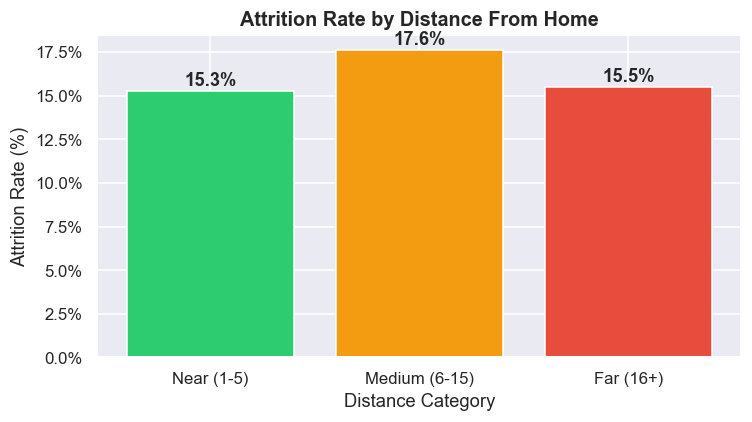

In [26]:
# ── 7d. Distance From Home vs Attrition ──────────────────────────────────────
# Bin distances into 3 groups
df['DistanceBin'] = pd.cut(df['DistanceFromHome'], bins=[0, 5, 15, 30], labels=['Near (1-5)', 'Medium (6-15)', 'Far (16+)'])
dist_attr = df.groupby('DistanceBin', observed=True)['Attrition_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dist_attr.index.astype(str), dist_attr.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
for bar, val in zip(bars, dist_attr.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Distance From Home', fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Distance Category')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

## 8. Manager Impact — YearsWithCurrManager vs Attrition

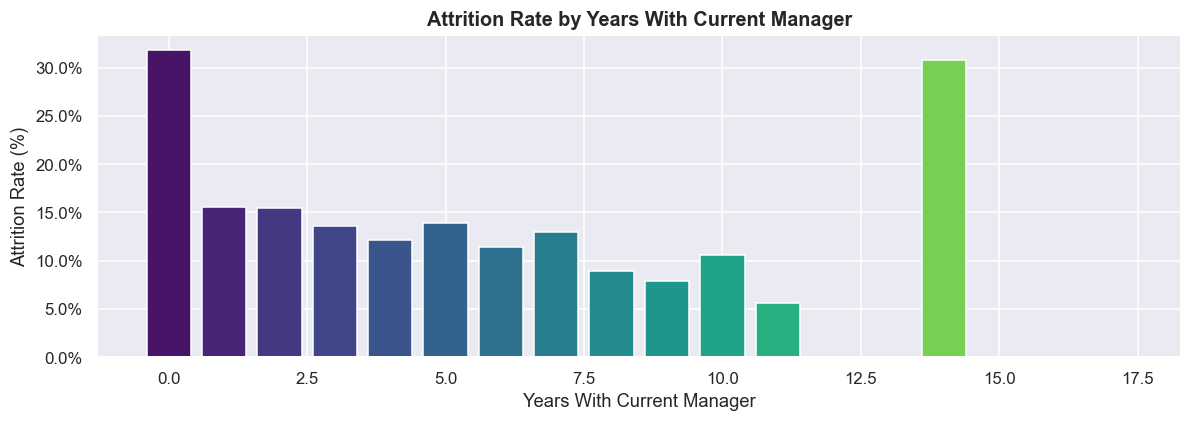

Insight: Employees who have been with the same manager for 0–1 years
tend to have the highest attrition — a sign of onboarding/fit issues or new manager transitions.


In [27]:
mgr_attr = df.groupby('YearsWithCurrManager')['Attrition_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(mgr_attr.index, mgr_attr.values, color=sns.color_palette('viridis', len(mgr_attr)))
ax.set_title('Attrition Rate by Years With Current Manager', fontsize=13, fontweight='bold')
ax.set_xlabel('Years With Current Manager')
ax.set_ylabel('Attrition Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print('Insight: Employees who have been with the same manager for 0–1 years')
print('tend to have the highest attrition — a sign of onboarding/fit issues or new manager transitions.')

## 9. Promotions & Stagnation Analysis

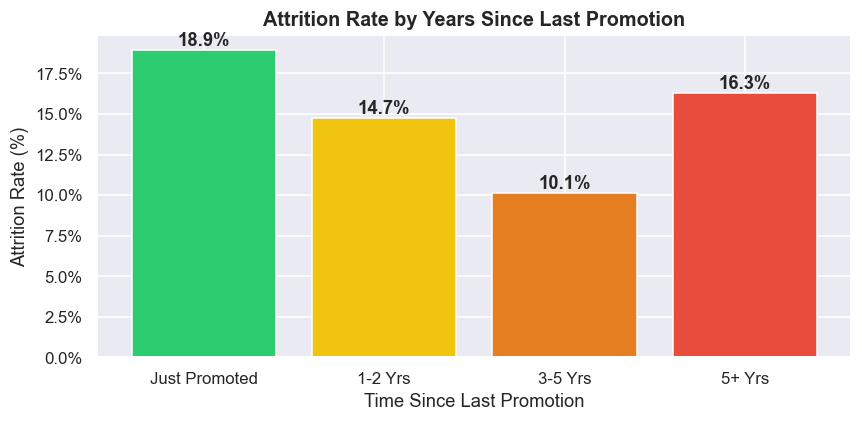


Insight: Stagnation (5+ years without promotion) correlates with higher attrition.


In [28]:
# Group promotion stagnation into bins
df['PromotionBin'] = pd.cut(df['YearsSinceLastPromotion'], 
                             bins=[-1, 0, 2, 5, 20], 
                             labels=['Just Promoted', '1-2 Yrs', '3-5 Yrs', '5+ Yrs'])
promo_attr = df.groupby('PromotionBin', observed=True)['Attrition_Binary'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(promo_attr.index.astype(str), promo_attr.values,
              color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
for bar, val in zip(bars, promo_attr.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Attrition Rate by Years Since Last Promotion', fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Time Since Last Promotion')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print('\nInsight: Stagnation (5+ years without promotion) correlates with higher attrition.')

## 10. Summary of Findings

| # | Finding | Key Insight |
|---|---------|-------------|
| 1 | **Department** | HR department has the highest attrition (~28%) |
| 2 | **Age** | Younger employees (< 35) leave significantly more |
| 3 | **Monthly Income** | Employees who leave earn considerably less on average |
| 4 | **Satisfaction** | Low Environment & Job Satisfaction = strong attrition predictor |
| 5 | **Business Travel** | Frequent travel is associated with higher burn-out & resignation |
| 6 | **Distance from Home** | Employees living far from office leave at higher rates |
| 7 | **Manager Tenure** | Employees <2 years with same manager show highest attrition |
| 8 | **Promotions** | Those not promoted in 5+ years leave at the highest rate |
| 9 | **Apriori Rules** | Key bundles: Sales + Marketing + Low EnvSat → Attrition=Yes |
| 10 | **Clusters** | 4 distinct employee personas found — one cluster is high-risk |
